In [1]:
# Cell: MULTIOMICS manual Protein/RNA feature evaluation + RF tuning
# No *_nz_feat.txt files are required; manual feature lists are used directly.

import re
import numpy as np
import pandas as pd
from pathlib import Path

from scipy.stats import randint
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder
RANDOM_STATE = 42
# ----------------------------
# 0) Paths (run from Protein_RNA/code/)
# ----------------------------
TISSUE = "A"
BASE_DIR = Path("..")                 # Protein_RNA/
DATA_DIR = BASE_DIR / "data"          # Protein_RNA/data/

# multiomics CSVs
X20_PATH = DATA_DIR / f"multiomics_X_2020_{TISSUE}.csv"
X21_PATH = DATA_DIR / f"multiomics_X_val_2021_{TISSUE}.csv"
Y20_PATH = DATA_DIR / f"multiomics_y_2020_{TISSUE}.csv"
Y21_PATH = DATA_DIR / f"multiomics_y_val_2021_{TISSUE}.csv"

# Output
FIG_DIR = Path("figure") / f"tissue_{TISSUE}"
FIG_DIR.mkdir(parents=True, exist_ok=True)

# ----------------------------
# 1) Load train (2020) / validation (2021) multiomics
# ----------------------------
X_train_df = pd.read_csv(X20_PATH)
X_valid_df = pd.read_csv(X21_PATH)
y_train_df = pd.read_csv(Y20_PATH)
y_valid_df = pd.read_csv(Y21_PATH)

# ---- ID + label column auto-detect
ID_CANDIDATES = ["join_key", "JoinKey", "Sample", "sample", "id", "ID"]
LABEL_CANDIDATES = ["label", "crop", "crops", "y", "target", "class"]

def pick_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None

ID_COL_X = pick_col(X_train_df, ID_CANDIDATES)
ID_COL_Y = pick_col(y_train_df, ID_CANDIDATES)
LABEL_COL = pick_col(y_train_df, LABEL_CANDIDATES)

if ID_COL_X is None or ID_COL_Y is None:
    raise ValueError(f"[ERROR] Could not find ID columns. X cols={list(X_train_df.columns)[:10]} y cols={list(y_train_df.columns)[:10]}")
if LABEL_COL is None:
    raise ValueError(f"[ERROR] Could not find label column in y. y columns={list(y_train_df.columns)}")

for df in [X_train_df, X_valid_df, y_train_df, y_valid_df]:
    if ID_COL_X in df.columns:
        df[ID_COL_X] = df[ID_COL_X].astype(str)
    if ID_COL_Y in df.columns:
        df[ID_COL_Y] = df[ID_COL_Y].astype(str)

def ensure_unique(df, col, name):
    if df[col].duplicated().any():
        dup = df.loc[df[col].duplicated(), col].iloc[0]
        raise ValueError(f"[ERROR] {name} has duplicated {col}: example={dup}")

ensure_unique(X_train_df, ID_COL_X, "X_train_df")
ensure_unique(X_valid_df, ID_COL_X, "X_valid_df")
ensure_unique(y_train_df, ID_COL_Y, "y_train_df")
ensure_unique(y_valid_df, ID_COL_Y, "y_valid_df")

# Align y to X by ID
y_train_df = y_train_df.set_index(ID_COL_Y).loc[X_train_df[ID_COL_X]].reset_index()
y_valid_df = y_valid_df.set_index(ID_COL_Y).loc[X_valid_df[ID_COL_X]].reset_index()

# Drop ID + numeric
X_train = X_train_df.drop(columns=[ID_COL_X]).apply(pd.to_numeric, errors="coerce")
X_valid = X_valid_df.drop(columns=[ID_COL_X]).apply(pd.to_numeric, errors="coerce")
X_valid = X_valid.reindex(columns=X_train.columns)

le = LabelEncoder()
y_np = le.fit_transform(y_train_df[LABEL_COL].astype(str).to_numpy())
y_va = le.transform(y_valid_df[LABEL_COL].astype(str).to_numpy())

print("[INFO] X_train:", X_train.shape)
print("[INFO] X_valid:", X_valid.shape)
print("[INFO] classes:", list(le.classes_))
print("[INFO] ID_COL_X:", ID_COL_X, "| ID_COL_Y:", ID_COL_Y, "| LABEL_COL:", LABEL_COL)



[INFO] X_train: (40, 17306)
[INFO] X_valid: (40, 17306)
[INFO] classes: ['CAC', 'CAS', 'CRA', 'HBB']
[INFO] ID_COL_X: join_key | ID_COL_Y: join_key | LABEL_COL: crops


In [2]:
# ----------------------------
# 2) Split multiomics columns into Protein/RNA
# ----------------------------
# This notebook no longer requires Prot_*_nz_feat.txt or RNA_*_nz_feat.txt.
# Only the manual feature lists below are used for Manual-Protein, Manual-RNA, and Manual-MIX.

all_feature_cols = list(X_train.columns)

def split_modal_cols(cols):
    prot = [c for c in cols if c.lower().startswith(("prot__", "prot_", "protein__", "protein_", "prot", "protein"))]
    rna  = [c for c in cols if c.lower().startswith(("rna__", "rna_", "transcript__", "transcript_", "rna", "transcript"))]
    if len(prot) == 0:
        prot = [c for c in cols if ("prot" in c.lower()) or ("protein" in c.lower())]
    if len(rna) == 0:
        rna  = [c for c in cols if ("rna" in c.lower()) or ("transcript" in c.lower())]
    return prot, rna

prot_cols, rna_cols = split_modal_cols(all_feature_cols)
if len(prot_cols) == 0 or len(rna_cols) == 0:
    raise ValueError(
        "[ERROR] Could not split multiomics columns into Protein/RNA by name.\n"
        "Need prefixes like prot__/rna__ or columns containing 'prot'/'rna'."
    )

# preserve original order
prot_cols = [c for c in all_feature_cols if c in set(prot_cols)]
rna_cols  = [c for c in all_feature_cols if c in set(rna_cols)]

name_to_global = {c: i for i, c in enumerate(all_feature_cols)}
print(f"[INFO] Detected Protein cols: {len(prot_cols)} | RNA cols: {len(rna_cols)} | Total: {len(all_feature_cols)}")

# ----------------------------
# 3) Manual feature lists
# ----------------------------
PROTEIN = [
    'XP_006562449',
    'NP_001035311',
    'NP_001014992',
]

RNA = [
    'LOC100577472',
    'LOC100576401',
    'LOC411734',
    'LOC113218651',
    'Cox6b1',
    'LOC414001',
    'LOC100577242',
    'LOC107963984',
    'LOC409353',
    'LOC724700',
    'LOC102655281',
    'LOC100577341',
    'Ecr',
    'LOC408556',
]

def canonical_id_from_col(colname: str):
    s = str(colname).strip()
    s = re.sub(
        r"^(prot__|rna__|prot_|rna_|protein__|protein_|transcript__|transcript_)",
        "",
        s,
        flags=re.IGNORECASE,
    )
    token = s.split(" ")[0].strip()
    token = re.sub(r"\.\d+$", "", token)
    return token

def canonical_id_from_txt(item: str):
    s = str(item).strip()
    s = s.split(" ")[0].split("\t")[0].split(",")[0].strip()
    s = re.sub(r"\.\d+$", "", s)
    return s

def select_manual_tokens_to_global(manual_list, modality_cols, label):
    token_to_cols = {}
    for c in modality_cols:
        tok = canonical_id_from_col(c)
        token_to_cols.setdefault(tok, []).append(c)

    matched, missing = [], []
    seen = set()

    # Keep the user-provided manual feature order.
    for item in manual_list:
        tok = canonical_id_from_txt(item)
        if tok in token_to_cols:
            for cname in token_to_cols[tok]:
                g = name_to_global[cname]
                if g not in seen:
                    matched.append(g)
                    seen.add(g)
        else:
            missing.append(tok)

    matched = np.asarray(matched, dtype=int)
    print(f"[INFO] {label} manual match: matched d={len(matched)} / want={len(manual_list)}")
    if missing:
        print(f"[WARN] {label} missing tokens: {missing}")
        print(f"[WARN] {label} sample modality tokens: {[canonical_id_from_col(x) for x in modality_cols[:10]]}")
    return matched

prot_manual_global = select_manual_tokens_to_global(PROTEIN, prot_cols, "Protein")
rna_manual_global  = select_manual_tokens_to_global(RNA,     rna_cols,  "RNA")

if len(prot_manual_global) == 0 or len(rna_manual_global) == 0:
    raise ValueError("[ERROR] Manual feature matching failed with 0 matched features. Check column names/tokens.")

# Stop early if the fusion table does not contain all requested manual features.
if len(prot_manual_global) < len(PROTEIN) or len(rna_manual_global) < len(RNA):
    raise ValueError(
        f"[ERROR] Manual feature matching is incomplete: "
        f"Protein matched {len(prot_manual_global)}/{len(PROTEIN)}, "
        f"RNA matched {len(rna_manual_global)}/{len(RNA)}. "
        "Use the full multiomics table containing these manual feature columns, "
        "or check the column-name prefixes/tokens above."
    )

mix_manual_global = np.concatenate([prot_manual_global, rna_manual_global]).astype(int)

print(f"[INFO] Manual-Protein d={len(prot_manual_global)}")
print(f"[INFO] Manual-RNA     d={len(rna_manual_global)}")
print(f"[INFO] Manual-MIX     d={len(mix_manual_global)}")

print("\n[CHECK] Manual-Protein columns in final order:")
print(list(X_train.columns[prot_manual_global]))

print("\n[CHECK] Manual-RNA columns in final order:")
print(list(X_train.columns[rna_manual_global]))


[INFO] Detected Protein cols: 5972 | RNA cols: 11334 | Total: 17306
[INFO] Protein manual match: matched d=3 / want=3
[INFO] RNA manual match: matched d=14 / want=14
[INFO] Manual-Protein d=3
[INFO] Manual-RNA     d=14
[INFO] Manual-MIX     d=17

[CHECK] Manual-Protein columns in final order:
['prot__XP_006562449', 'prot__NP_001035311', 'prot__NP_001014992']

[CHECK] Manual-RNA columns in final order:
['rna__LOC100577472', 'rna__LOC100576401', 'rna__LOC411734', 'rna__LOC113218651', 'rna__Cox6b1', 'rna__LOC414001', 'rna__LOC100577242', 'rna__LOC107963984', 'rna__LOC409353', 'rna__LOC724700', 'rna__LOC102655281', 'rna__LOC100577341', 'rna__Ecr', 'rna__LOC408556']



[INFO] Starting RF tuning for manual feature sets only:
[CV] Manual-Protein best roc_auc_ovr = 1.0000
[CV] Manual-RNA best roc_auc_ovr = 0.9875
[CV] Manual-MIX best roc_auc_ovr = 1.0000

[INFO] Feature-set summary after tuning:
             name  n_features  cv_roc_auc_ovr
0  Manual-Protein           3          1.0000
1      Manual-RNA          14          0.9875
2      Manual-MIX          17          1.0000


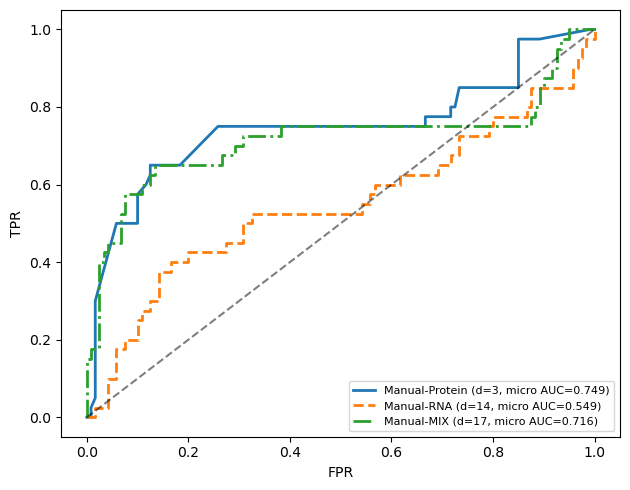


===== FINAL SUMMARY =====
             name  n_features  cv_roc_auc_ovr  valid_micro_auc  \
0  Manual-Protein           3          1.0000         0.748542   
1      Manual-RNA          14          0.9875         0.548958   
2      Manual-MIX          17          1.0000         0.715833   

   valid_macro_auc  
0         0.778333  
1         0.575000  
2         0.766667  


In [3]:
# ----------------------------
# 4) RF tuning for manual feature sets only
# ----------------------------
from scipy.stats import randint
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

GA_LINESTYLES = ["-", "--", "-."]
PARAM_DIST = {
    "n_estimators": randint(100, 650),
    "max_depth": [None, 8, 12],
    "max_features": ["sqrt", "log2", 0.7, 1],
    "min_samples_split": randint(2, 20),
    "min_samples_leaf": randint(1, 8),
    "bootstrap": [True],
    "max_samples": [None, 0.6, 0.8, 1.0],
    "class_weight": [None, "balanced"],
    "criterion": ["gini", "entropy"],
}

STAGE1_N_ITER = globals().get("STAGE1_N_ITER", 80)
cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=2042)
SCORING = "roc_auc_ovr"
RANDOM_STATE = 42

def tune_rf_for_features(feature_idx, label):
    feature_idx = np.asarray(feature_idx, dtype=int)
    if feature_idx.size == 0:
        raise ValueError(f"[ERROR] {label} has 0 features. Check manual feature matching above.")

    X_sub = X_train.iloc[:, feature_idx].to_numpy()
    rs = RandomizedSearchCV(
        estimator=RandomForestClassifier(random_state=2042, n_jobs=-1),
        param_distributions=PARAM_DIST,
        n_iter=STAGE1_N_ITER,
        scoring=SCORING,
        cv=cv5,
        n_jobs=-1,
        random_state=2042,
        verbose=0,
    )
    rs.fit(X_sub, y_np)

    best_params = dict(rs.best_params_)
    best_params.pop("random_state", None)
    best_params.pop("n_jobs", None)
    if best_params.get("bootstrap") is False:
        best_params.pop("max_samples", None)

    print(f"[CV] {label} best {SCORING} = {rs.best_score_:.4f}")
    return best_params, float(rs.best_score_)

# ----------------------------
# 5) Feature sets
# ----------------------------
feature_sets = [
    {"name": "Manual-Protein", "cols": prot_manual_global},
    {"name": "Manual-RNA", "cols": rna_manual_global},
    {"name": "Manual-MIX", "cols": mix_manual_global},
]

print("\n[INFO] Starting RF tuning for manual feature sets only:")
for fs in feature_sets:
    params, cv_score = tune_rf_for_features(fs["cols"], fs["name"])
    fs["best_params"] = params
    fs["cv_score"] = cv_score

print("\n[INFO] Feature-set summary after tuning:")
print(pd.DataFrame([
    {
        "name": fs["name"],
        "n_features": int(len(fs["cols"])),
        "cv_roc_auc_ovr": fs["cv_score"],
    }
    for fs in feature_sets
]))

# --------------------------------------------------------
# 6) Final train on 2020 & temporal validation on 2021
# --------------------------------------------------------
plt.figure(figsize=(6.4, 5.0))
valid_rows = []

n_classes = int(len(np.unique(y_np)))
classes = np.arange(n_classes)
y_onehot_va = label_binarize(y_va, classes=classes)

for i, fs in enumerate(feature_sets):
    params = dict(fs["best_params"])
    cols = np.asarray(fs["cols"], dtype=int)

    Xtr_sub = X_train.iloc[:, cols].to_numpy()
    Xva_sub = X_valid.iloc[:, cols].to_numpy()

    clf = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1, **params)
    clf.fit(Xtr_sub, y_np)
    proba_va = clf.predict_proba(Xva_sub)

    auc_va_micro = roc_auc_score(y_va, proba_va, multi_class="ovr", average="micro")
    auc_va_macro = roc_auc_score(y_va, proba_va, multi_class="ovr", average="macro")

    fpr, tpr, _ = roc_curve(y_onehot_va.ravel(), proba_va.ravel())

    plt.plot(
        fpr,
        tpr,
        lw=2,
        linestyle=GA_LINESTYLES[min(i, len(GA_LINESTYLES) - 1)],
        label=f"{fs['name']} (d={len(cols)}, micro AUC={auc_va_micro:.3f})",
    )

    valid_rows.append({
        "name": fs["name"],
        "n_features": int(Xtr_sub.shape[1]),
        "cv_roc_auc_ovr": float(fs["cv_score"]),
        "valid_micro_auc": float(auc_va_micro),
        "valid_macro_auc": float(auc_va_macro),
    })

plt.plot([0, 1], [0, 1], "--", color="black", alpha=0.5)
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()

valid_summary_df = pd.DataFrame(valid_rows)
print("\n===== FINAL SUMMARY =====")
print(valid_summary_df[["name", "n_features", "cv_roc_auc_ovr", "valid_micro_auc", "valid_macro_auc"]])


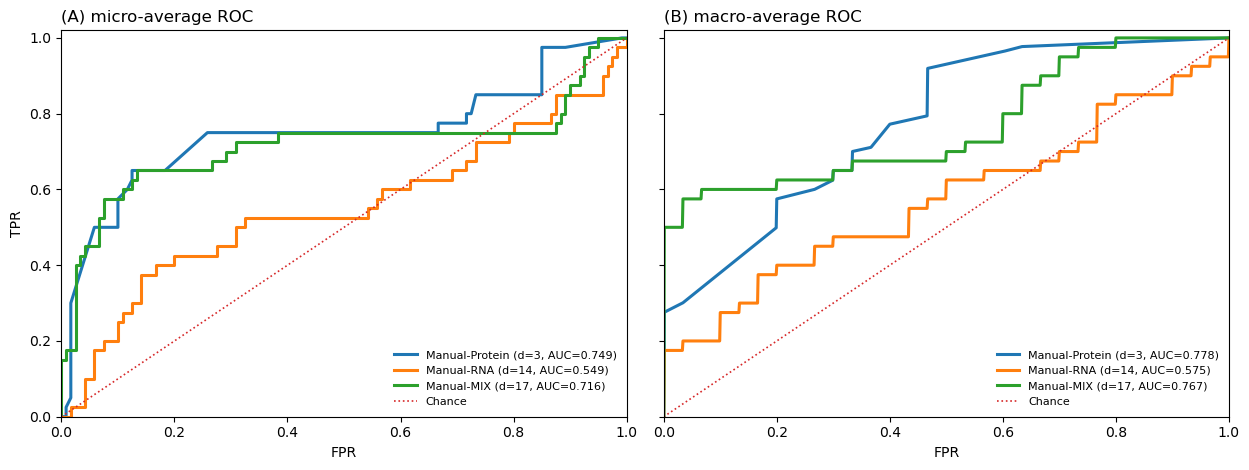

[SAVED] figure\tissue_A\temporal_valid_roc_manual_protein_rna_mix.pdf
[SAVED] figure\tissue_A\temporal_valid_roc_manual_protein_rna_mix.png


In [4]:
# ============================================================
# ROC figure: Manual-Protein vs Manual-RNA vs Manual-MIX
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.preprocessing import label_binarize

n_classes = int(len(np.unique(y_np)))
classes = np.arange(n_classes)
y_onehot_va = label_binarize(y_va, classes=classes)
all_fpr = np.linspace(0, 1, 1001)

fig, axes = plt.subplots(1, 2, figsize=(12.6, 4.8), sharey=True)

for fs in feature_sets:
    if "best_params" not in fs:
        raise ValueError(f"{fs['name']} has no best_params. Run tuning cell first.")

    cols = np.asarray(fs["cols"], dtype=int)
    params = dict(fs["best_params"])

    Xtr = X_train.iloc[:, cols].to_numpy()
    Xva = X_valid.iloc[:, cols].to_numpy()

    clf = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1, **params)
    clf.fit(Xtr, y_np)
    proba_va = clf.predict_proba(Xva)

    # micro
    fpr_micro, tpr_micro, _ = roc_curve(y_onehot_va.ravel(), proba_va.ravel())
    auc_micro = roc_auc_score(y_va, proba_va, multi_class="ovr", average="micro")
    axes[0].plot(
        fpr_micro,
        tpr_micro,
        lw=2.2,
        label=f"{fs['name']} (d={len(cols)}, AUC={auc_micro:.3f})",
    )

    # macro
    mean_tpr = np.zeros_like(all_fpr)
    for k in range(n_classes):
        fpr_k, tpr_k, _ = roc_curve(y_onehot_va[:, k], proba_va[:, k])
        mean_tpr += np.interp(all_fpr, fpr_k, tpr_k)
    mean_tpr /= n_classes
    mean_tpr[0] = 0.0
    mean_tpr[-1] = 1.0

    auc_macro = roc_auc_score(y_va, proba_va, multi_class="ovr", average="macro")
    axes[1].plot(
        all_fpr,
        mean_tpr,
        lw=2.2,
        label=f"{fs['name']} (d={len(cols)}, AUC={auc_macro:.3f})",
    )

axes[0].plot([0, 1], [0, 1], ls=":", lw=1.2, label="Chance")
axes[1].plot([0, 1], [0, 1], ls=":", lw=1.2, label="Chance")

axes[0].set_title("(A) micro-average ROC", loc="left")
axes[1].set_title("(B) macro-average ROC", loc="left")
axes[0].set_xlabel("FPR")
axes[1].set_xlabel("FPR")
axes[0].set_ylabel("TPR")

for ax in axes:
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1.02)
    ax.legend(loc="lower right", frameon=False, fontsize=8)

fig.tight_layout()

out_pdf = FIG_DIR / "temporal_valid_roc_manual_protein_rna_mix.pdf"
out_png = FIG_DIR / "temporal_valid_roc_manual_protein_rna_mix.png"
fig.savefig(out_pdf, bbox_inches="tight")
fig.savefig(out_png, dpi=300, bbox_inches="tight")
plt.show()

print("[SAVED]", out_pdf)
print("[SAVED]", out_png)


In [5]:
import numpy as np
import shap
from sklearn.ensemble import RandomForestClassifier

RANDOM_STATE = 42

mix_name = next(fs["name"] for fs in feature_sets
                if fs["name"].lower().startswith(("manual-mix", "mix")))
mix_fs = next(fs for fs in feature_sets if fs["name"] == mix_name)

mix_cols   = np.asarray(mix_fs["cols"], dtype=int)
mix_params = dict(mix_fs["best_params"])

print(f"[INFO] Using MIX subset: {mix_name} (d={len(mix_cols)})")

Xtr = X_train.iloc[:, mix_cols]
y_tr = np.asarray(y_np).ravel()

rf = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1, **mix_params)
rf.fit(Xtr, y_tr)

BG_N   = min(500, len(Xtr))
EVAL_N = min(2000, len(Xtr))

X_bg   = Xtr.sample(BG_N, random_state=RANDOM_STATE)
X_eval = Xtr.sample(EVAL_N, random_state=RANDOM_STATE)

# index-safe label alignment
y_eval = y_tr[Xtr.index.get_indexer(X_eval.index)]

feature_names = list(Xtr.columns)
K = int(len(np.unique(y_tr)))

explainer = shap.TreeExplainer(rf, data=X_bg, feature_perturbation="interventional")
shv = explainer.shap_values(X_eval)

# Robust handling across SHAP versions:
# - old versions: list of K arrays, each (n_samples, n_features)
# - newer versions: ndarray with shape (n_samples, n_features, K)
if isinstance(shv, list):
    S = np.stack([np.asarray(a) for a in shv], axis=0)  # (K, n, p)
else:
    arr = np.asarray(shv)
    if arr.ndim == 3 and arr.shape[-1] == K:
        S = np.moveaxis(arr, -1, 0)  # (K, n, p)
    elif arr.ndim == 3 and arr.shape[0] == K:
        S = arr
    else:
        raise ValueError(f"Unexpected SHAP shape: {arr.shape}")

print("[INFO] X_eval:", X_eval.shape, "| K:", K, "| S:", S.shape)


c:\Users\junse\miniconda3\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[INFO] Using MIX subset: Manual-MIX (d=17)
[INFO] X_eval: (40, 17) | K: 4 | S: (4, 40, 17)



===== Manual feature temporal validation metrics =====
             name  n_features  macro_precision  macro_recall  macro_f1
0  Manual-Protein           3         0.479677         0.625  0.539099
1      Manual-RNA          14         0.586207         0.425  0.361160
2      Manual-MIX          17         0.575980         0.650  0.597643


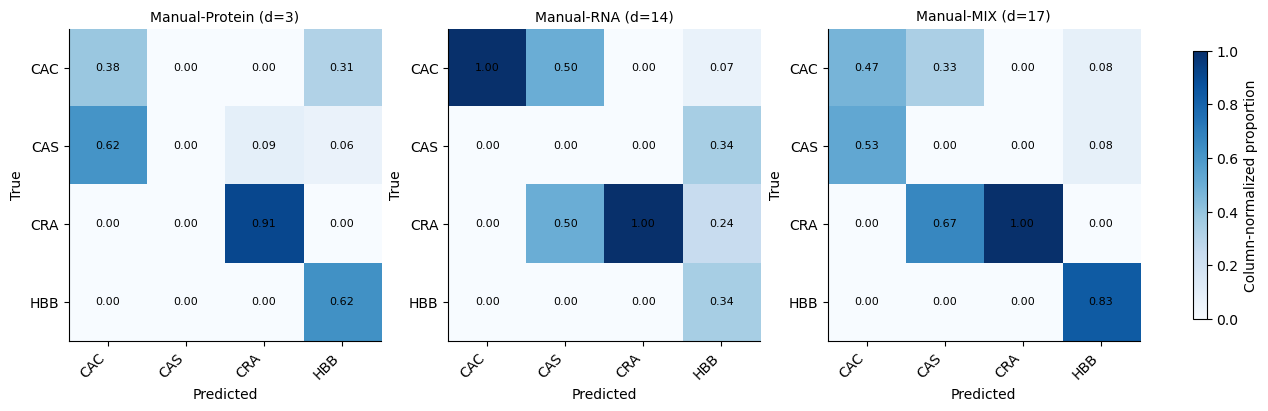

[SAVED] figure\tissue_A\fig_confusion_2021_manual_protein_rna_mix_precision.pdf
[SAVED] figure\tissue_A\fig_confusion_2021_manual_protein_rna_mix_precision.png


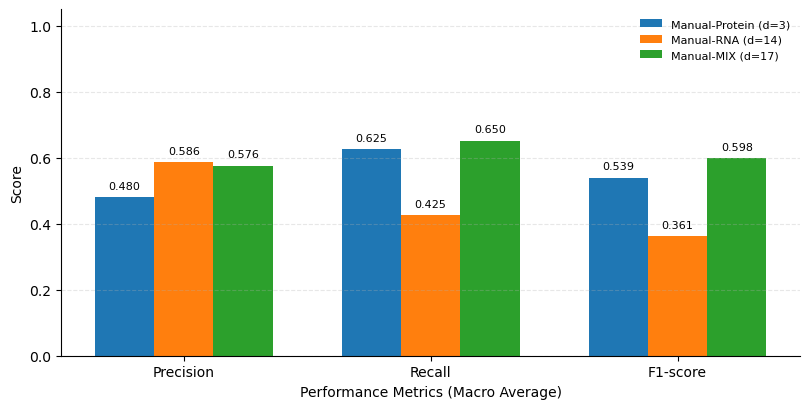

[SAVED] figure\tissue_A\fig_macro_metrics_2021_manual_protein_rna_mix.pdf
[SAVED] figure\tissue_A\fig_macro_metrics_2021_manual_protein_rna_mix.png


In [6]:
# ============================================================
# Paper-style figures: Manual-Protein vs Manual-RNA vs Manual-MIX
# (A) Precision-normalized confusion matrices
# (B) Macro Precision / Recall / F1 bar plot
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix,
    precision_recall_fscore_support,
    precision_score,
    recall_score,
    f1_score,
)

plt.rcParams.update({
    "font.size": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

def fit_predict_for_fs(fs):
    cols = np.asarray(fs["cols"], dtype=int)
    params = dict(fs["best_params"])

    Xtr_sub = X_train.iloc[:, cols].to_numpy()
    Xva_sub = X_valid.iloc[:, cols].to_numpy()

    clf = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1, **params)
    clf.fit(Xtr_sub, y_np)
    yhat = clf.predict(Xva_sub)
    return yhat

K = int(len(np.unique(y_np)))
labels = np.arange(K)
class_labels = list(le.classes_)

pred_cache = {}
metric_rows = []

for fs in feature_sets:
    yhat = fit_predict_for_fs(fs)
    pred_cache[fs["name"]] = yhat

    macro_precision = precision_score(y_va, yhat, average="macro", zero_division=0)
    macro_recall = recall_score(y_va, yhat, average="macro", zero_division=0)
    macro_f1 = f1_score(y_va, yhat, average="macro", zero_division=0)

    metric_rows.append({
        "name": fs["name"],
        "n_features": int(len(fs["cols"])),
        "macro_precision": float(macro_precision),
        "macro_recall": float(macro_recall),
        "macro_f1": float(macro_f1),
    })

metric_df = pd.DataFrame(metric_rows)
print("\n===== Manual feature temporal validation metrics =====")
print(metric_df)

def col_normalize(cm):
    return cm / np.maximum(cm.sum(axis=0, keepdims=True), 1)

# ----------------------------
# (A) Confusion matrices
# ----------------------------
fig, axes = plt.subplots(1, len(feature_sets), figsize=(4.2 * len(feature_sets), 4.0), constrained_layout=True)
if len(feature_sets) == 1:
    axes = [axes]

last_im = None
for ax, fs in zip(axes, feature_sets):
    cm = confusion_matrix(y_va, pred_cache[fs["name"]], labels=labels)
    cm_norm = col_normalize(cm)

    last_im = ax.imshow(cm_norm, vmin=0, vmax=1, cmap="Blues")
    ax.set_title(f"{fs['name']} (d={len(fs['cols'])})", fontsize=10)
    ax.set_xticks(np.arange(K))
    ax.set_yticks(np.arange(K))
    ax.set_xticklabels(class_labels, rotation=45, ha="right")
    ax.set_yticklabels(class_labels)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")

    for i in range(K):
        for j in range(K):
            ax.text(j, i, f"{cm_norm[i, j]:.2f}", ha="center", va="center", fontsize=8)

cbar = fig.colorbar(last_im, ax=axes, shrink=0.85)
cbar.set_label("Column-normalized proportion")

out_pdf = FIG_DIR / "fig_confusion_2021_manual_protein_rna_mix_precision.pdf"
out_png = FIG_DIR / "fig_confusion_2021_manual_protein_rna_mix_precision.png"
fig.savefig(out_pdf, bbox_inches="tight")
fig.savefig(out_png, dpi=300, bbox_inches="tight")
plt.show()

print("[SAVED]", out_pdf)
print("[SAVED]", out_png)

# ----------------------------
# (B) Macro metric bar plot
# ----------------------------
metric_names = ["macro_precision", "macro_recall", "macro_f1"]
x = np.arange(len(metric_names))
width = 0.24

fig, ax = plt.subplots(figsize=(8.2, 4.2))
offsets = np.linspace(-width, width, len(feature_sets))

for offset, row in zip(offsets, metric_rows):
    scores = [row[m] for m in metric_names]
    ax.bar(x + offset, scores, width, label=f"{row['name']} (d={row['n_features']})")
    for xi, score in zip(x + offset, scores):
        ax.text(xi, score + 0.02, f"{score:.3f}", ha="center", va="bottom", fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(["Precision", "Recall", "F1-score"])
ax.set_ylim(0, 1.05)
ax.set_xlabel("Performance Metrics (Macro Average)")
ax.set_ylabel("Score")
ax.legend(loc="upper right", frameon=False, fontsize=8)
ax.grid(axis="y", linestyle="--", alpha=0.3)

fig.tight_layout()

out_pdf = FIG_DIR / "fig_macro_metrics_2021_manual_protein_rna_mix.pdf"
out_png = FIG_DIR / "fig_macro_metrics_2021_manual_protein_rna_mix.png"
fig.savefig(out_pdf, bbox_inches="tight")
fig.savefig(out_png, dpi=300, bbox_inches="tight")
plt.show()

print("[SAVED]", out_pdf)
print("[SAVED]", out_png)


In [7]:
# # ============================================================
# # LATE FUSION
# # Protein  : from fusion dataset (X_train, X_valid)
# # RNA      : from separate RNA dataset
# # Then average validation probabilities
# # ============================================================

# import numpy as np
# import pandas as pd
# from sklearn.ensemble import RandomForestClassifier

# RANDOM_STATE = 42

# # ----------------------------
# # 0) Pick feature sets
# # ----------------------------
# names = [fs["name"] for fs in feature_sets]

# def pick_fs_by_prefix(prefixes, prefer_exact=None):
#     low = {fs["name"].lower(): fs for fs in feature_sets}
#     if prefer_exact:
#         for ex in prefer_exact:
#             if ex.lower() in low:
#                 return low[ex.lower()]
#     for fs in feature_sets:
#         ln = fs["name"].lower()
#         if any(ln.startswith(p) for p in prefixes):
#             return fs
#     return None

# prot_fs = pick_fs_by_prefix(
#     prefixes=("manual-protein", "protein"),
#     prefer_exact=["Manual-Protein", "Protein"]
# )
# rna_fs = pick_fs_by_prefix(
#     prefixes=("manual-rna", "rna"),
#     prefer_exact=["Manual-RNA", "RNA"]
# )

# if prot_fs is None:
#     raise ValueError(f"No Protein feature set found. Available names: {names}")
# if rna_fs is None:
#     raise ValueError(f"No RNA feature set found. Available names: {names}")

# if "best_params" not in prot_fs or "best_params" not in rna_fs:
#     raise ValueError("Run the RF tuning cell first so both feature sets have best_params.")

# print(f"[INFO] Protein set = {prot_fs['name']} | d={len(prot_fs['cols'])}")
# print(f"[INFO] RNA set     = {rna_fs['name']} | d={len(rna_fs['cols'])}")

# # ----------------------------
# # 1) Protein from fusion dataset
# # ----------------------------
# Xtr_prot = X_train.iloc[:, prot_fs["cols"]].to_numpy()
# Xva_prot = X_valid.iloc[:, prot_fs["cols"]].to_numpy()

# # fusion dataset validation IDs / y_true
# fusion_valid_ids = X_valid_df[ID_COL_X].astype(str).values
# y_true_fusion = y_va.copy()

# # ----------------------------
# # 2) RNA from separate dataset
# # ----------------------------
# id_col_rna_tr = pick_col(rna_X_tr_ref, ID_CANDIDATES)
# id_col_rna_va = pick_col(rna_X_va_ref, ID_CANDIDATES)
# id_col_rna_y  = pick_col(rna_y_tr_ref, ID_CANDIDATES)
# lbl_col_rna   = pick_col(rna_y_tr_ref, LABEL_CANDIDATES)

# if any(v is None for v in [id_col_rna_tr, id_col_rna_va, id_col_rna_y, lbl_col_rna]):
#     raise ValueError("Could not detect RNA ID/label columns.")

# Xtr_rna = rna_X_tr_ref[RNA].apply(pd.to_numeric, errors="coerce").to_numpy()
# Xva_rna = rna_X_va_ref[RNA].apply(pd.to_numeric, errors="coerce").to_numpy()

# y_tr_rna_aligned = (
#     rna_y_tr_ref
#     .set_index(id_col_rna_y)
#     .loc[rna_X_tr_ref[id_col_rna_tr].astype(str)]
#     .reset_index()
# )

# def process_labels(labels, encoder):
#     try:
#         return pd.to_numeric(labels).astype(int).values
#     except Exception:
#         return encoder.transform(labels.astype(str)).values

# y_tr_rna = process_labels(y_tr_rna_aligned[lbl_col_rna], le)

# # ----------------------------
# # 3) Train separate RF models
# # ----------------------------
# clf_prot = RandomForestClassifier(
#     random_state=RANDOM_STATE,
#     n_jobs=-1,
#     **dict(prot_fs["best_params"])
# )
# clf_rna = RandomForestClassifier(
#     random_state=RANDOM_STATE,
#     n_jobs=-1,
#     **dict(rna_fs["best_params"])
# )

# clf_prot.fit(Xtr_prot, y_np)      # protein uses fusion train labels
# clf_rna.fit(Xtr_rna, y_tr_rna)    # RNA uses separate train labels

# proba_prot = clf_prot.predict_proba(Xva_prot)
# proba_rna  = clf_rna.predict_proba(Xva_rna)

# print("[SUCCESS] Protein(fusion) / RNA(separate) predictions completed.")

# # ----------------------------
# # 4) Align by validation ID
# # ----------------------------
# rna_valid_ids = rna_X_va_ref[id_col_rna_va].astype(str).values

# df_proba_prot = pd.DataFrame(proba_prot, index=fusion_valid_ids)
# df_proba_rna  = pd.DataFrame(proba_rna,  index=rna_valid_ids)

# common_ids = pd.Index(fusion_valid_ids).intersection(pd.Index(rna_valid_ids))

# if len(common_ids) == 0:
#     raise ValueError("No overlapping validation IDs between fusion Protein and separate RNA datasets.")

# proba_prot_aligned = df_proba_prot.loc[common_ids].to_numpy()
# proba_rna_aligned  = df_proba_rna.loc[common_ids].to_numpy()

# # fusion y_true도 same common_ids로 정렬
# df_ytrue_fusion = pd.Series(y_true_fusion, index=fusion_valid_ids)
# y_true_common = df_ytrue_fusion.loc[common_ids].to_numpy()

# # ----------------------------
# # 5) Late fusion
# # ----------------------------
# proba_late = 0.5 * proba_prot_aligned + 0.5 * proba_rna_aligned
# yhat_late = np.argmax(proba_late, axis=1)

# print("[INFO] # common validation IDs:", len(common_ids))
# print("[INFO] proba_prot_aligned shape:", proba_prot_aligned.shape)
# print("[INFO] proba_rna_aligned  shape:", proba_rna_aligned.shape)
# print("[INFO] proba_late shape:", proba_late.shape)

# # ----------------------------
# # 6) Cache
# # ----------------------------
# late_fusion_cache = {
#     "name": "LateFusion (Protein=fusion dataset, RNA=separate dataset)",
#     "protein": {
#         "source": "fusion",
#         "cols": np.asarray(prot_fs["cols"]),
#         "params": dict(prot_fs["best_params"]),
#         "n_features": int(len(prot_fs["cols"])),
#     },
#     "rna": {
#         "source": "separate",
#         "cols": np.arange(len(RNA)),
#         "params": dict(rna_fs["best_params"]),
#         "n_features": int(len(RNA)),
#     },
#     "valid": {
#         "ids": np.asarray(common_ids),
#         "y_true": np.asarray(y_true_common),
#         "proba": np.asarray(proba_late),
#         "y_pred": np.asarray(yhat_late),
#     }
# }

In [8]:
# # ============================================================
# # ROC: Baseline vs Late Fusion
# # One FIGURE with two panels:
# #   (A) micro-average OVR ROC
# #   (B) macro-average OVR ROC
# # Save name kept the same as before
# # ============================================================

# import numpy as np
# import matplotlib.pyplot as plt
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.metrics import roc_curve, roc_auc_score
# from sklearn.preprocessing import label_binarize

# # ----------------------------
# # 0) pick baseline feature set
# # ----------------------------
# baseline_fs = next((fs for fs in feature_sets if fs["name"].lower().startswith("baseline")), None)
# if baseline_fs is None:
#     raise ValueError("No Baseline found in feature_sets.")
# if "best_params" not in baseline_fs:
#     raise ValueError("Baseline must already have best_params. Run the tuning cell first.")

# baseline_cols = np.asarray(baseline_fs["cols"], dtype=int)
# baseline_params = dict(baseline_fs["best_params"])

# # ----------------------------
# # 1) fit baseline on 2020 -> predict on 2021
# # ----------------------------
# Xtr_base = X_train.iloc[:, baseline_cols].to_numpy()
# Xva_base = X_valid.iloc[:, baseline_cols].to_numpy()

# clf_base = RandomForestClassifier(
#     random_state=RANDOM_STATE,
#     n_jobs=-1,
#     **baseline_params
# )
# clf_base.fit(Xtr_base, y_np)

# proba_base = clf_base.predict_proba(Xva_base)
# yhat_base = np.argmax(proba_base, axis=1)

# # ----------------------------
# # 2) get late fusion outputs
# # ----------------------------
# y_true = np.asarray(late_fusion_cache["valid"]["y_true"])
# proba_late = np.asarray(late_fusion_cache["valid"]["proba"])
# yhat_late = np.asarray(late_fusion_cache["valid"]["y_pred"])

# # sanity
# if not np.array_equal(y_true, y_va):
#     print("[WARN] y_true from late_fusion_cache differs from y_va. Using cache y_true.")

# n_classes = int(len(np.unique(y_np)))
# classes = np.arange(n_classes)

# y_onehot = label_binarize(y_true, classes=classes)
# all_fpr = np.linspace(0, 1, 1001)

# # ----------------------------
# # 3) helper for macro curve
# # ----------------------------
# def compute_micro_macro_roc(y_true, proba, classes, all_fpr):
#     y_onehot = label_binarize(y_true, classes=classes)

#     # micro
#     fpr_micro, tpr_micro, _ = roc_curve(y_onehot.ravel(), proba.ravel())
#     auc_micro = roc_auc_score(y_true, proba, multi_class="ovr", average="micro")

#     # macro
#     mean_tpr = np.zeros_like(all_fpr)
#     for k in range(len(classes)):
#         fpr_k, tpr_k, _ = roc_curve(y_onehot[:, k], proba[:, k])
#         mean_tpr += np.interp(all_fpr, fpr_k, tpr_k)

#     mean_tpr /= len(classes)
#     mean_tpr[0] = 0.0
#     mean_tpr[-1] = 1.0

#     auc_macro = roc_auc_score(y_true, proba, multi_class="ovr", average="macro")

#     return {
#         "micro": {"fpr": fpr_micro, "tpr": tpr_micro, "auc": float(auc_micro)},
#         "macro": {"fpr": all_fpr.copy(), "tpr": mean_tpr, "auc": float(auc_macro)},
#     }

# base_roc = compute_micro_macro_roc(y_true, proba_base, classes, all_fpr)
# late_roc = compute_micro_macro_roc(y_true, proba_late, classes, all_fpr)

# # ----------------------------
# # 4) plot
# # ----------------------------
# fig, axes = plt.subplots(1, 2, figsize=(12.6, 4.8), sharey=True)

# # (A) micro
# ax = axes[0]
# ax.plot(
#     base_roc["micro"]["fpr"], base_roc["micro"]["tpr"],
#     lw=2.2,
#     label=f"Baseline (d={len(baseline_cols)}, AUC={base_roc['micro']['auc']:.3f})"
# )
# ax.plot(
#     late_roc["micro"]["fpr"], late_roc["micro"]["tpr"],
#     lw=2.2, ls="--",
#     label=(
#         f"Late Fusion "
#         f"(Prot d={late_fusion_cache['protein']['n_features']}, "
#         f"RNA d={late_fusion_cache['rna']['n_features']}, "
#         f"AUC={late_roc['micro']['auc']:.3f})"
#     )
# )
# ax.plot([0, 1], [0, 1], ls=":", lw=1.2, label="Chance")
# ax.set_xlim(0, 1)
# ax.set_ylim(0, 1.02)
# ax.set_xlabel("FPR (micro)")
# ax.set_ylabel("TPR")
# ax.text(0.02, 0.98, "(A) micro", transform=ax.transAxes, ha="left", va="top", fontsize=11)
# ax.legend(loc="lower right", frameon=False, fontsize=9)

# # (B) macro
# ax = axes[1]
# ax.plot(
#     base_roc["macro"]["fpr"], base_roc["macro"]["tpr"],
#     lw=2.2,
#     label=f"Baseline (d={len(baseline_cols)}, AUC={base_roc['macro']['auc']:.3f})"
# )
# ax.plot(
#     late_roc["macro"]["fpr"], late_roc["macro"]["tpr"],
#     lw=2.2, ls="--",
#     label=(
#         f"Late Fusion "
#         f"(Prot d={late_fusion_cache['protein']['n_features']}, "
#         f"RNA d={late_fusion_cache['rna']['n_features']}, "
#         f"AUC={late_roc['macro']['auc']:.3f})"
#     )
# )
# ax.plot([0, 1], [0, 1], ls=":", lw=1.2, label="Chance")
# ax.set_xlim(0, 1)
# ax.set_ylim(0, 1.02)
# ax.set_xlabel("FPR (macro)")
# ax.text(0.02, 0.98, "(B) macro", transform=ax.transAxes, ha="left", va="top", fontsize=11)
# ax.legend(loc="lower right", frameon=False, fontsize=9)

# fig.tight_layout()

# out_pdf = FIG_DIR / "temporal_valid_roc_micro_macro_latefusion_protein_rna.pdf"
# out_png = FIG_DIR / "temporal_valid_roc_micro_macro_latefusion_protein_rna.png"
# fig.savefig(out_pdf, bbox_inches="tight")
# fig.savefig(out_png, dpi=300, bbox_inches="tight")
# plt.show()

# print("[SAVED]", out_pdf)
# print("[SAVED]", out_png)

# print(f"[RESULT] Baseline micro AUC    = {base_roc['micro']['auc']:.4f}")
# print(f"[RESULT] Late Fusion micro AUC = {late_roc['micro']['auc']:.4f}")
# print(f"[RESULT] Baseline macro AUC    = {base_roc['macro']['auc']:.4f}")
# print(f"[RESULT] Late Fusion macro AUC = {late_roc['macro']['auc']:.4f}")

In [9]:
# # ============================================================
# # Paper-style Figures (Temporal Valid = 2021)
# # (A) Confusion matrices: Baseline vs Late Fusion
# # (B) Per-class Precision + Recall bar plot: Baseline vs Late Fusion
# # Save names kept the same as before
# # ============================================================

# import numpy as np
# import matplotlib.pyplot as plt
# from sklearn.metrics import confusion_matrix, precision_score, recall_score

# plt.rcParams.update({
#     "font.size": 10,
#     "axes.spines.top": False,
#     "axes.spines.right": False,
# })

# CMAP = "Blues"
# COLOR_BASE = "#7A7A7A"
# COLOR_LATE = "#4C78A8"
# GRID_ALPHA = 0.25

# # ----------------------------
# # 0) labels / predictions
# # ----------------------------
# y_true = np.asarray(late_fusion_cache["valid"]["y_true"])
# y_pred_late = np.asarray(late_fusion_cache["valid"]["y_pred"])

# # baseline prediction already computed in ROC cell:
# #   yhat_base
# # if not, compute it here again
# if "yhat_base" not in globals():
#     baseline_fs = next((fs for fs in feature_sets if fs["name"].lower().startswith("baseline")), None)
#     if baseline_fs is None:
#         raise ValueError("No Baseline found in feature_sets.")
#     if "best_params" not in baseline_fs:
#         raise ValueError("Baseline must already have best_params. Run the tuning cell first.")

#     baseline_cols = np.asarray(baseline_fs["cols"], dtype=int)
#     baseline_params = dict(baseline_fs["best_params"])

#     Xtr_base = X_train.iloc[:, baseline_cols].to_numpy()
#     Xva_base = X_valid.iloc[:, baseline_cols].to_numpy()

#     clf_base = RandomForestClassifier(
#         random_state=RANDOM_STATE,
#         n_jobs=-1,
#         **baseline_params
#     )
#     clf_base.fit(Xtr_base, y_np)
#     proba_base = clf_base.predict_proba(Xva_base)
#     yhat_base = np.argmax(proba_base, axis=1)

# y_pred_base = np.asarray(yhat_base)

# K = int(len(np.unique(y_true)))
# labels = np.arange(K)
# class_labels = list(le.classes_)

# print("[INFO] Plot class_labels:", class_labels)

# # ----------------------------
# # helper
# # ----------------------------
# def col_normalize(cm):
#     return cm / np.maximum(cm.sum(axis=0, keepdims=True), 1)

# def plot_cm(ax, cm_norm, panel_label):
#     im = ax.imshow(cm_norm, vmin=0, vmax=1, cmap=CMAP)
#     ax.set_xticks(np.arange(K))
#     ax.set_yticks(np.arange(K))
#     ax.set_xticklabels(class_labels, rotation=45, ha="right")
#     ax.set_yticklabels(class_labels)
#     ax.set_xlabel("Predicted")
#     ax.set_ylabel("True")

#     ax.text(0.02, 1.03, panel_label, transform=ax.transAxes,
#             ha="left", va="bottom", fontsize=11)

#     for i in range(K):
#         for j in range(K):
#             ax.text(j, i, f"{cm_norm[i, j]:.2f}", ha="center", va="center", fontsize=8)

#     return im

# # ----------------------------
# # 1) Confusion matrices
# # ----------------------------
# cm_base = confusion_matrix(y_true, y_pred_base, labels=labels)
# cm_late = confusion_matrix(y_true, y_pred_late, labels=labels)

# cm_base_norm = col_normalize(cm_base)
# cm_late_norm = col_normalize(cm_late)

# fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.2), constrained_layout=True)

# _  = plot_cm(axes[0], cm_base_norm, "A  Baseline")
# im = plot_cm(axes[1], cm_late_norm, "B  Late Fusion")

# cbar = fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.9)
# cbar.set_label("Proportion")

# out_pdf = FIG_DIR / "fig_confusion_2021_latefusion_protein_rna_precision.pdf"
# out_png = FIG_DIR / "fig_confusion_2021_latefusion_protein_rna_precision.png"
# fig.savefig(out_pdf, bbox_inches="tight")
# fig.savefig(out_png, dpi=300, bbox_inches="tight")
# plt.show()

# print("[SAVED]", out_pdf)
# print("[SAVED]", out_png)

# # ----------------------------
# # 2) Per-class Precision + Recall
# # ----------------------------
# prec_base = precision_score(y_true, y_pred_base, average=None, labels=labels, zero_division=0)
# rec_base  = recall_score(y_true, y_pred_base, average=None, labels=labels, zero_division=0)

# prec_late = precision_score(y_true, y_pred_late, average=None, labels=labels, zero_division=0)
# rec_late  = recall_score(y_true, y_pred_late, average=None, labels=labels, zero_division=0)

# macro_prec_base = float(precision_score(y_true, y_pred_base, average="macro", zero_division=0))
# macro_rec_base  = float(recall_score(y_true, y_pred_base, average="macro", zero_division=0))

# macro_prec_late = float(precision_score(y_true, y_pred_late, average="macro", zero_division=0))
# macro_rec_late  = float(recall_score(y_true, y_pred_late, average="macro", zero_division=0))

# x = np.arange(K)
# width = 0.18

# fig, ax = plt.subplots(figsize=(9.2, 4.2))

# ax.bar(
#     x - 1.5*width, prec_base, width,
#     color=COLOR_BASE, alpha=0.55,
#     label=f"Baseline Precision (macro={macro_prec_base:.3f})"
# )
# ax.bar(
#     x - 0.5*width, rec_base, width,
#     color=COLOR_BASE, alpha=1.00,
#     label=f"Baseline Recall (macro={macro_rec_base:.3f})"
# )
# ax.bar(
#     x + 0.5*width, prec_late, width,
#     color=COLOR_LATE, alpha=0.55,
#     label=f"Late Fusion Precision (macro={macro_prec_late:.3f})"
# )
# ax.bar(
#     x + 1.5*width, rec_late, width,
#     color=COLOR_LATE, alpha=1.00,
#     label=f"Late Fusion Recall (macro={macro_rec_late:.3f})"
# )

# ax.set_xticks(x)
# ax.set_xticklabels(class_labels, rotation=45, ha="right")
# ax.set_ylabel("Score")
# ax.set_xlabel("Class")
# ax.set_ylim(0, 1.0)
# ax.grid(axis="y", alpha=GRID_ALPHA)
# ax.legend(frameon=False, ncol=2)

# fig.tight_layout()

# out_pdf = FIG_DIR / "fig_precision_recall_per_class_2021_latefusion_protein_rna.pdf"
# out_png = FIG_DIR / "fig_precision_recall_per_class_2021_latefusion_protein_rna.png"
# fig.savefig(out_pdf, bbox_inches="tight")
# fig.savefig(out_png, dpi=300, bbox_inches="tight")
# plt.show()

# print("[SAVED]", out_pdf)
# print("[SAVED]", out_png)

# print("\n===== 2021 Per-class Precision/Recall =====")
# for i, lab in enumerate(class_labels):
#     print(
#         f"{str(lab):>6s} | "
#         f"Base(P)={prec_base[i]:.3f} Base(R)={rec_base[i]:.3f} | "
#         f"Late(P)={prec_late[i]:.3f} Late(R)={rec_late[i]:.3f}"
#     )

# print(f"\nMacro Precision | Baseline={macro_prec_base:.3f} | Late Fusion={macro_prec_late:.3f}")
# print(f"Macro Recall    | Baseline={macro_rec_base:.3f} | Late Fusion={macro_rec_late:.3f}")

In [10]:
# # ============================================================
# # LATE FUSION (Protein + RNA only)
# # Train separate RF models on:
# #   - Manual-Protein (기존 Fusion 데이터셋 사용)
# #   - Manual-RNA (Cell 7에 정의된 RNA 독립 데이터셋 & 고정 파라미터 사용)
# # Then average predicted probabilities on 2021 validation
# # ============================================================

# import numpy as np
# import pandas as pd
# from sklearn.ensemble import RandomForestClassifier

# RANDOM_STATE = 42

# # ----------------------------
# # 1) 단백질(Protein) 모델 학습 (Fusion 데이터셋 기준)
# # ----------------------------
# prot_cols = np.asarray(prot_fs["cols"], dtype=int)
# prot_params = dict(prot_fs["best_params"])

# Xtr_prot = X_train.iloc[:, prot_cols].to_numpy()
# Xva_prot = X_valid.iloc[:, prot_cols].to_numpy()

# clf_prot = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1, **prot_params)
# clf_prot.fit(Xtr_prot, y_np)
# proba_prot = clf_prot.predict_proba(Xva_prot)

# # ----------------------------
# # 2) RNA 모델 학습 (준서님의 Cell 7 로직 완벽 적용)
# # ----------------------------
# rna_params = dict(rna_fs["best_params"]) 

# Xtr_rna = rna_X_tr_ref[RNA].apply(pd.to_numeric, errors='coerce').to_numpy()
# Xva_rna = rna_X_va_ref[RNA].apply(pd.to_numeric, errors='coerce').to_numpy()

# id_col_rna_tr = pick_col(rna_X_tr_ref, ID_CANDIDATES)
# id_col_rna_va = pick_col(rna_X_va_ref, ID_CANDIDATES)
# lbl_col_rna = pick_col(rna_y_tr_ref, LABEL_CANDIDATES)

# y_tr_aligned = rna_y_tr_ref.set_index(pick_col(rna_y_tr_ref, ID_CANDIDATES)).loc[rna_X_tr_ref[id_col_rna_tr]].reset_index()
# y_va_aligned = rna_y_va_ref.set_index(pick_col(rna_y_va_ref, ID_CANDIDATES)).loc[rna_X_va_ref[id_col_rna_va]].reset_index()

# def process_labels(labels, encoder):
#     try:
#         return pd.to_numeric(labels).astype(int).values
#     except:
#         return encoder.transform(labels.astype(str)).values

# y_tr_sub = process_labels(y_tr_aligned[lbl_col_rna], le)

# clf_rna = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1, **rna_params)
# clf_rna.fit(Xtr_rna, y_tr_sub)
# proba_rna = clf_rna.predict_proba(Xva_rna)

# print("[SUCCESS] RNA 독립 데이터셋 매칭 및 예측 완료.")

# # ----------------------------
# # 3) Late Fusion (★버그 수정: 환자 ID 기준으로 완벽 정렬 후 평균★)
# # ----------------------------
# # 1. RNA 확률에 RNA 검증셋의 ID를 인덱스로 부여
# df_proba_rna = pd.DataFrame(proba_rna, index=rna_X_va_ref[id_col_rna_va].astype(str))

# # 2. 퓨전 검증셋(X_valid_df)의 ID 순서 추출
# target_ids = X_valid_df[ID_COL_X].astype(str)

# # 3. RNA 확률의 순서를 퓨전셋 ID 순서에 맞춰 재정렬 (Align)
# df_proba_rna_aligned = df_proba_rna.reindex(target_ids)

# # 매칭되지 않는 샘플이 있다면 기본값 처리 (클래스 갯수만큼 균등 확률)
# n_classes = len(le.classes_)
# df_proba_rna_aligned = df_proba_rna_aligned.fillna(1.0 / n_classes)

# # 배열로 다시 변환
# proba_rna_aligned = df_proba_rna_aligned.to_numpy()

# # 4. 이제 환자(샘플) 순서가 100% 일치하므로 안전하게 평균 계산!
# proba_late = 0.5 * proba_prot + 0.5 * proba_rna_aligned
# yhat_late = np.argmax(proba_late, axis=1)

# print("[INFO] proba_prot shape:", proba_prot.shape)
# print("[INFO] proba_rna  shape:", proba_rna.shape)
# print("[INFO] proba_late shape:", proba_late.shape)

# # 다음 Bar Plot 등에 쓸 수 있도록 결과 캐싱
# late_fusion_cache = {
#     "name": "LateFusion (Protein + RNA)",
#     "protein": {
#         "cols": prot_cols,
#         "params": prot_params,
#         "n_features": int(len(prot_cols)),
#     },
#     "rna": {
#         "cols": np.arange(len(RNA)),
#         "params": rna_params,
#         "n_features": int(len(RNA)),
#     },
#     "valid": {
#         "y_true": np.asarray(y_va),
#         "proba": np.asarray(proba_late),
#         "y_pred": np.asarray(yhat_late),
#     }
# }

[SUCCESS] Protein: d=3 features, params loaded, prediction complete
[SUCCESS] RNA: d=14 features, params loaded, prediction complete
[SUCCESS] RNA + Protein: d=17 features, params loaded, prediction complete


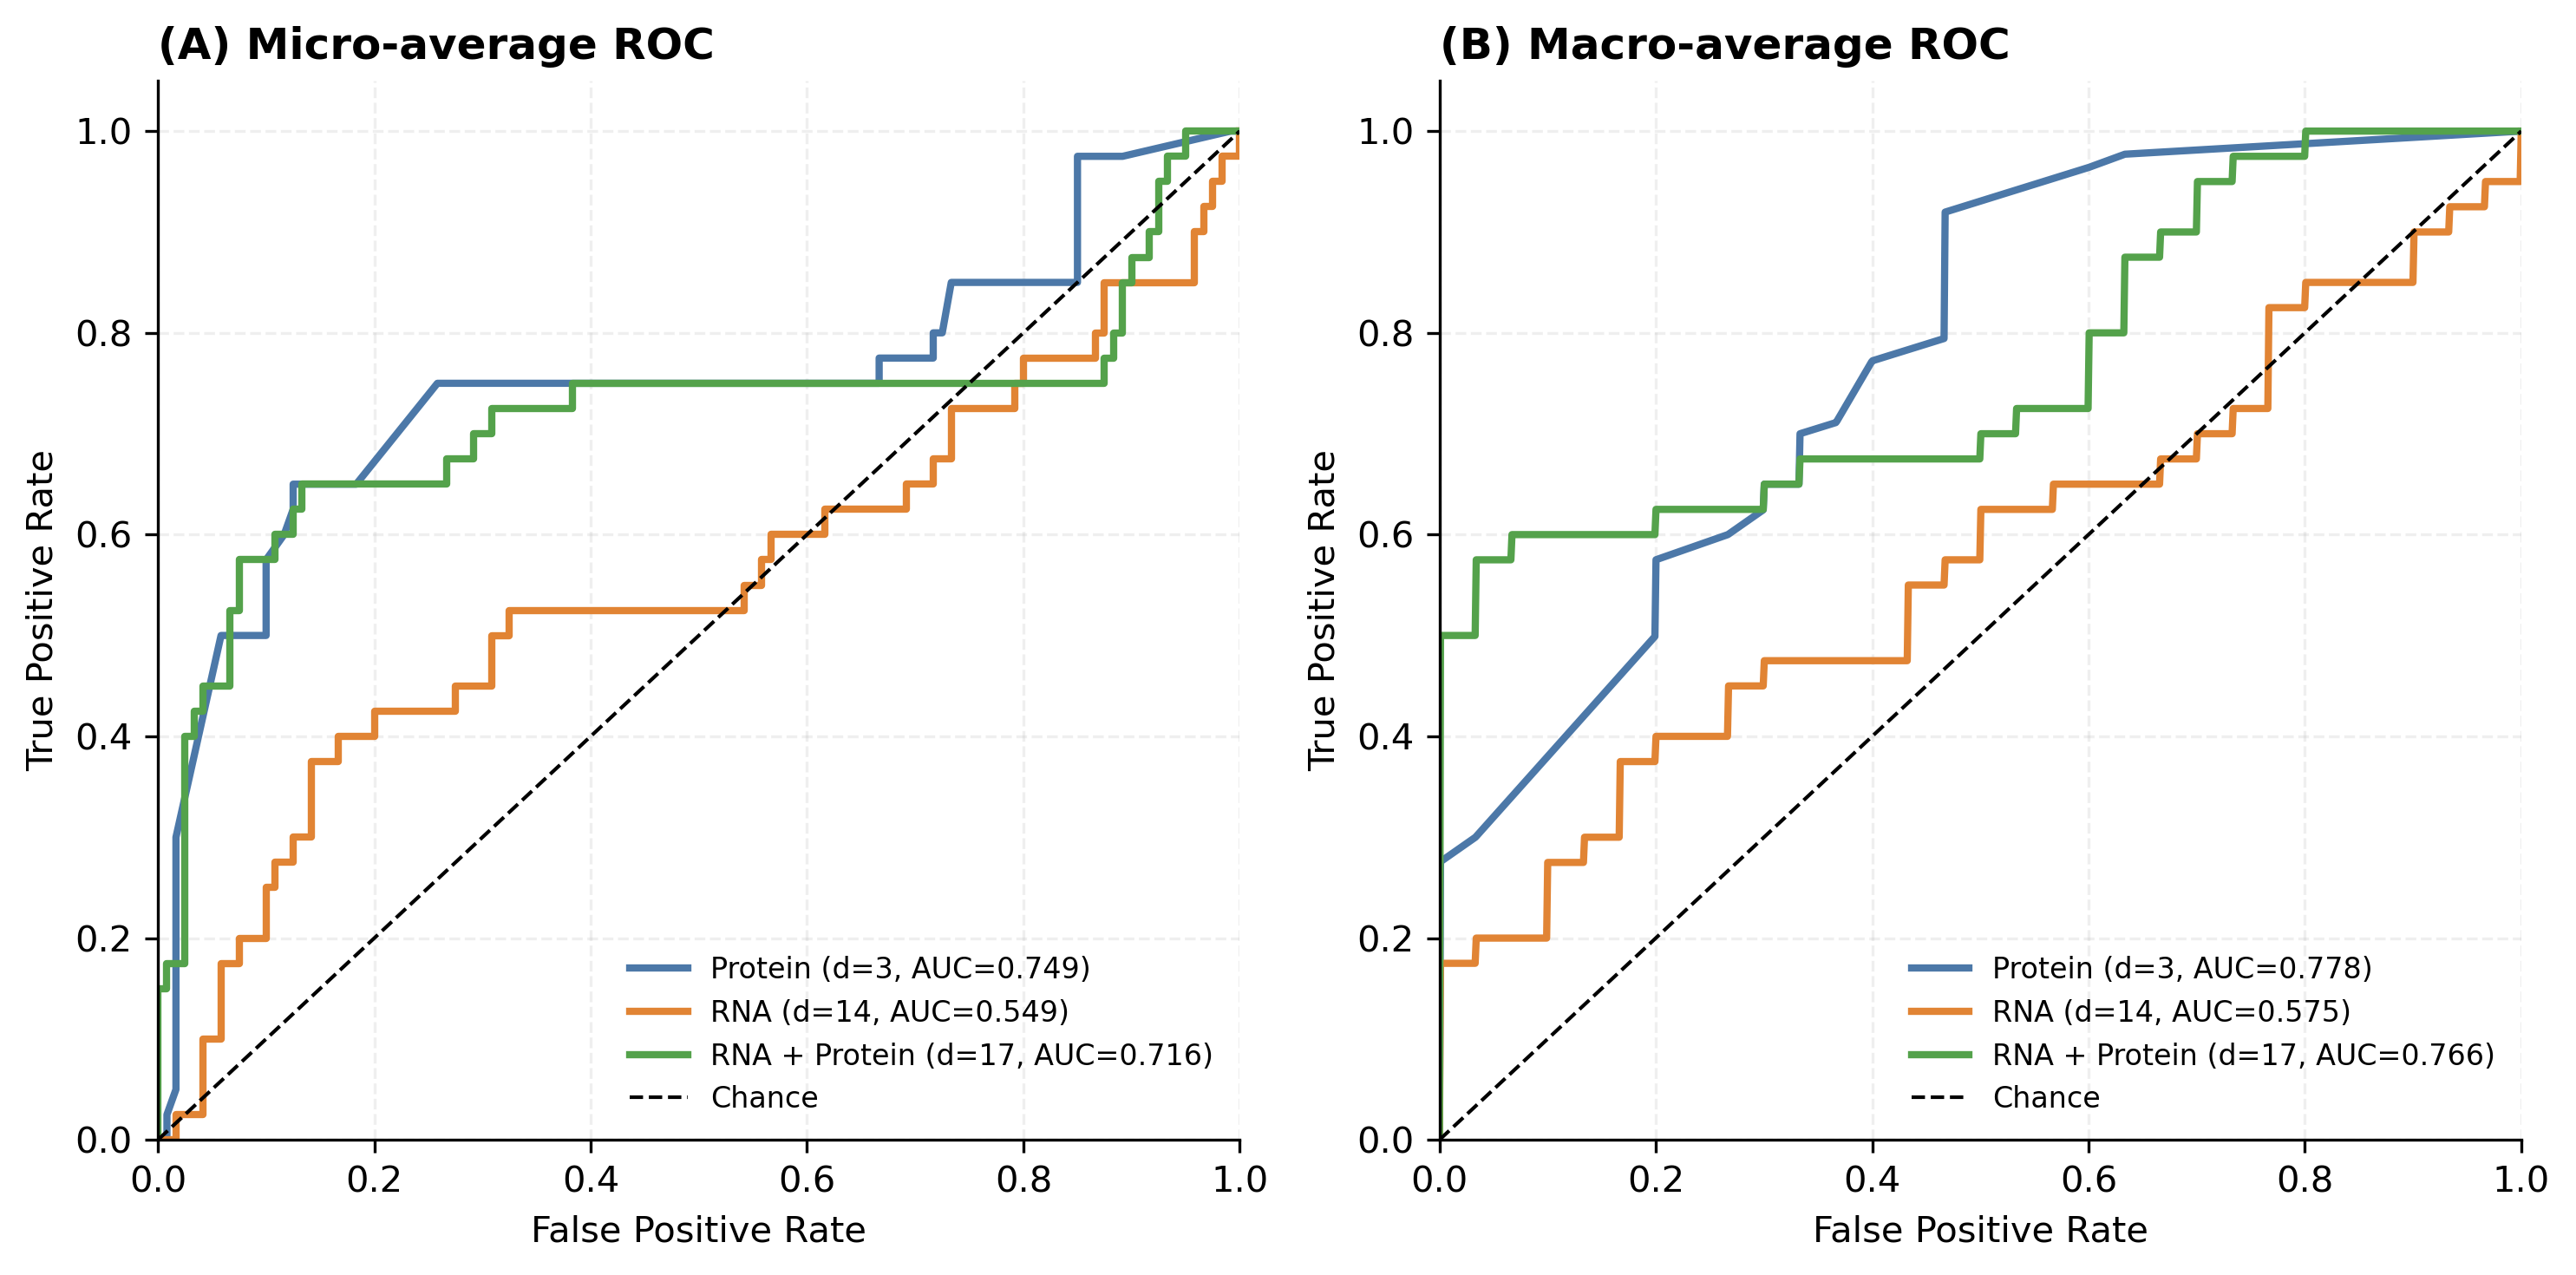

[SUCCESS] ROC plot saved to: figure\tissue_A\ROC_Final_EarlyFusion_ManualCustom_TissueA.pdf
[SUCCESS] ROC plot saved to: figure\tissue_A\ROC_Final_EarlyFusion_ManualCustom_TissueA.png

===== ManualCustom Protein/RNA/MIX Summary =====
        Modality  n_features  Micro AUC  Macro AUC  Macro Precision  \
0        Protein           3   0.748542   0.778333         0.479677   
1            RNA          14   0.548958   0.575000         0.586207   
2  RNA + Protein          17   0.715833   0.766667         0.575980   

   Macro Recall  Macro F1  
0         0.625  0.539099  
1         0.425  0.361160  
2         0.650  0.597643  


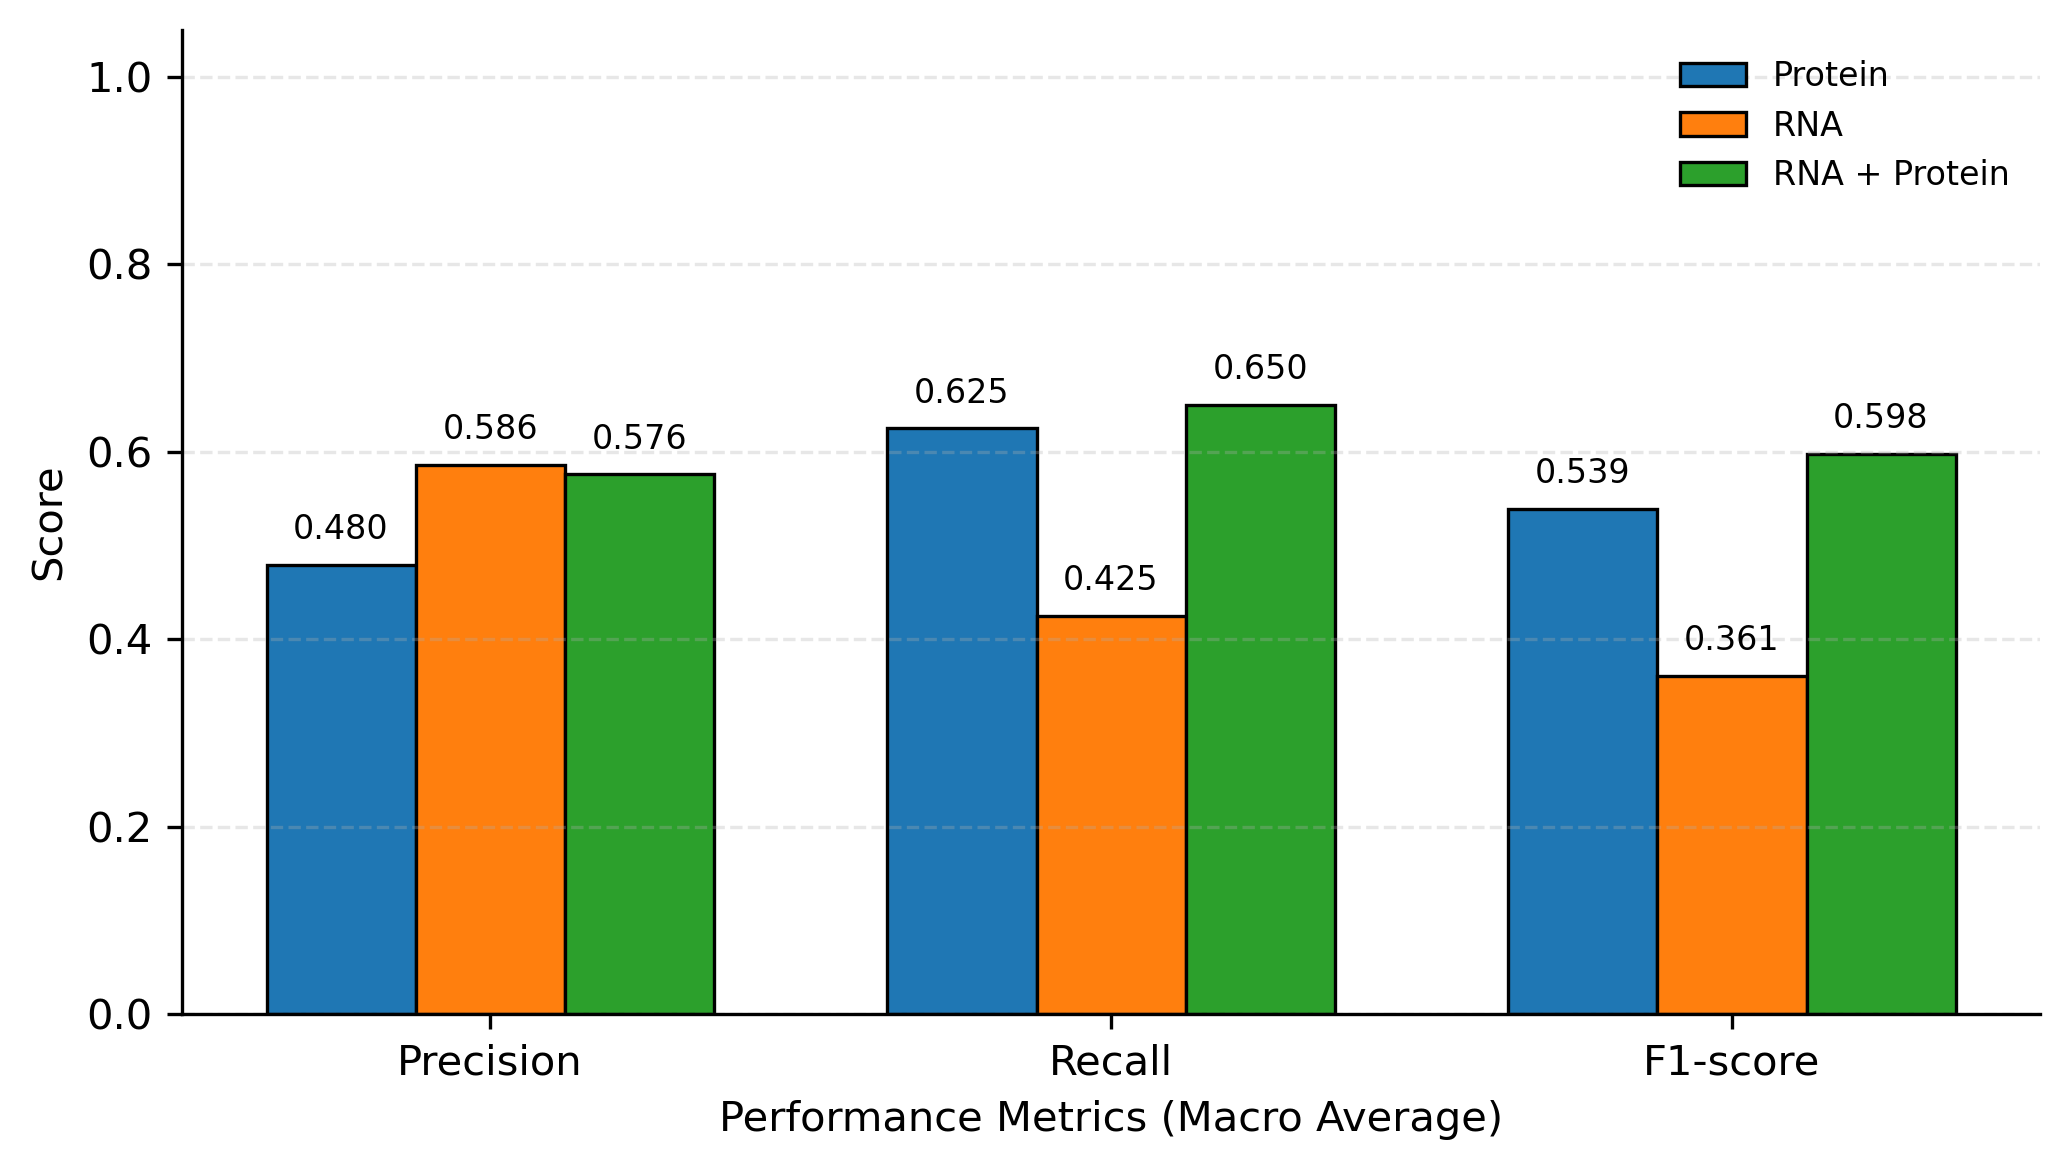

[SUCCESS] Bar plot saved to: figure\tissue_A\BarPlot_Final_EarlyFusion_ManualCustom_TissueA.pdf
[SUCCESS] Bar plot saved to: figure\tissue_A\BarPlot_Final_EarlyFusion_ManualCustom_TissueA.png


In [11]:
# ============================================================
# [EARLY FUSION: Custom Manual Protein + Custom Manual RNA]
# Protein, RNA, and MIX are all evaluated from the same aligned
# multiomics table using the matched manual columns from Cell 4.
# This avoids the old KeyError from reloading RNA/svm_filtered_data.
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    precision_recall_fscore_support,
    roc_curve,
    auc,
    roc_auc_score,
)
from sklearn.preprocessing import label_binarize

RANDOM_STATE = 42

# --------------------------------------------------------
# 1) Feature sets 선택
# --------------------------------------------------------
fs_prot = next(fs for fs in feature_sets if fs["name"] == "Manual-Protein")
fs_rna  = next(fs for fs in feature_sets if fs["name"] == "Manual-RNA")
fs_mix  = next(fs for fs in feature_sets if fs["name"] == "Manual-MIX")

plot_feature_sets = [
    ("Protein", fs_prot, "#4C78A8"),
    ("RNA", fs_rna, "#E18434"),
    ("RNA + Protein", fs_mix, "#54A24B"),
]

# --------------------------------------------------------
# 2) Train on 2020, predict on 2021 using matched fusion columns
# --------------------------------------------------------
plot_configs = []
for label, fs, color in plot_feature_sets:
    cols = np.asarray(fs["cols"], dtype=int)
    params = dict(fs["best_params"])

    Xtr_sub = X_train.iloc[:, cols].to_numpy()
    Xva_sub = X_valid.iloc[:, cols].to_numpy()

    clf = RandomForestClassifier(
        random_state=RANDOM_STATE,
        n_jobs=-1,
        **params,
    )
    clf.fit(Xtr_sub, y_np)
    proba = clf.predict_proba(Xva_sub)

    plot_configs.append({
        "proba": proba,
        "y_true": np.asarray(y_va, dtype=int),
        "label": label,
        "color": color,
        "n_features": int(len(cols)),
    })

    print(f"[SUCCESS] {label}: d={len(cols)} features, params loaded, prediction complete")

# --------------------------------------------------------
# 3) Plot configs
# --------------------------------------------------------
n_classes = len(le.classes_)
classes = np.arange(n_classes)
tissue_id = f"Tissue{TISSUE}"

# ============================================================
# [시각화 1] ROC Plot
# ============================================================
fig_roc, axes = plt.subplots(1, 2, figsize=(10, 5), dpi=300)

for config in plot_configs:
    P = config["proba"]
    y_true_cur = np.asarray(config["y_true"], dtype=int)
    Y_bin_cur = label_binarize(y_true_cur, classes=classes)

    color = config["color"]
    label = config["label"]
    d = config["n_features"]

    # Micro ROC
    fpr_micro, tpr_micro, _ = roc_curve(Y_bin_cur.ravel(), P.ravel())
    micro_auc = auc(fpr_micro, tpr_micro)

    axes[0].plot(
        fpr_micro,
        tpr_micro,
        color=color,
        lw=2,
        label=f"{label} (d={d}, AUC={micro_auc:.3f})",
    )

    # Macro ROC
    all_fpr = np.linspace(0.0, 1.0, 1000)
    mean_tpr = np.zeros_like(all_fpr)

    for i in range(n_classes):
        fpr_i, tpr_i, _ = roc_curve(Y_bin_cur[:, i], P[:, i])
        mean_tpr += np.interp(all_fpr, fpr_i, tpr_i)

    mean_tpr /= n_classes
    mean_tpr[0] = 0.0
    mean_tpr[-1] = 1.0
    macro_auc = auc(all_fpr, mean_tpr)

    axes[1].plot(
        all_fpr,
        mean_tpr,
        color=color,
        lw=2,
        label=f"{label} (d={d}, AUC={macro_auc:.3f})",
    )

for i, ax in enumerate(axes):
    ax.plot([0, 1], [0, 1], "k--", lw=1, label="Chance")
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1.05])
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title(
        ["(A) Micro-average ROC", "(B) Macro-average ROC"][i],
        fontsize=12,
        fontweight="bold",
        loc="left",
    )
    ax.legend(loc="lower right", frameon=False, fontsize=8)
    ax.grid(alpha=0.2, linestyle="--")

fig_roc.tight_layout()
out_roc_pdf = FIG_DIR / f"ROC_Final_EarlyFusion_ManualCustom_{tissue_id}.pdf"
out_roc_png = FIG_DIR / f"ROC_Final_EarlyFusion_ManualCustom_{tissue_id}.png"
fig_roc.savefig(out_roc_pdf, bbox_inches="tight", format="pdf")
fig_roc.savefig(out_roc_png, bbox_inches="tight", dpi=300)
plt.show()
print(f"[SUCCESS] ROC plot saved to: {out_roc_pdf}")
print(f"[SUCCESS] ROC plot saved to: {out_roc_png}")

# ============================================================
# [시각화 2] Bar Plot: macro Precision / Recall / F1
# ============================================================
summary_rows = []
for config in plot_configs:
    P = config["proba"]
    y_true_cur = np.asarray(config["y_true"], dtype=int)
    y_pred = np.argmax(P, axis=1)

    micro_auc = roc_auc_score(y_true_cur, P, multi_class="ovr", average="micro")
    macro_auc = roc_auc_score(y_true_cur, P, multi_class="ovr", average="macro")

    p, r, f1, _ = precision_recall_fscore_support(
        y_true_cur,
        y_pred,
        average=None,
        labels=classes,
        zero_division=0,
    )

    summary_rows.append({
        "Modality": config["label"],
        "n_features": config["n_features"],
        "Micro AUC": float(micro_auc),
        "Macro AUC": float(macro_auc),
        "Macro Precision": float(np.mean(p)),
        "Macro Recall": float(np.mean(r)),
        "Macro F1": float(np.mean(f1)),
    })

summary_df = pd.DataFrame(summary_rows)
print("\n===== ManualCustom Protein/RNA/MIX Summary =====")
print(summary_df)

metric_names = ["Macro Precision", "Macro Recall", "Macro F1"]
x = np.arange(len(metric_names))
width = 0.24

fig_bar, ax_bar = plt.subplots(figsize=(7, 4), dpi=300)
for offset, row in zip([-width, 0, width], summary_rows):
    scores = [row[m] for m in metric_names]
    ax_bar.bar(
        x + offset,
        scores,
        width,
        label=row["Modality"],
        edgecolor="black",
        linewidth=0.8,
    )
    for xi, score in zip(x + offset, scores):
        ax_bar.text(xi, score + 0.02, f"{score:.3f}", ha="center", va="bottom", fontsize=8)

ax_bar.set_xticks(x)
ax_bar.set_xticklabels(["Precision", "Recall", "F1-score"])
ax_bar.set_ylim((0, 1.05))
ax_bar.set_xlabel("Performance Metrics (Macro Average)")
ax_bar.set_ylabel("Score")
ax_bar.legend(loc="upper right", frameon=False, fontsize=8)
ax_bar.grid(axis="y", linestyle="--", alpha=0.3)
fig_bar.tight_layout()

out_bar_pdf = FIG_DIR / f"BarPlot_Final_EarlyFusion_ManualCustom_{tissue_id}.pdf"
out_bar_png = FIG_DIR / f"BarPlot_Final_EarlyFusion_ManualCustom_{tissue_id}.png"
fig_bar.savefig(out_bar_pdf, bbox_inches="tight", format="pdf")
fig_bar.savefig(out_bar_png, bbox_inches="tight", dpi=300)
plt.show()
print(f"[SUCCESS] Bar plot saved to: {out_bar_pdf}")
print(f"[SUCCESS] Bar plot saved to: {out_bar_png}")
